# Pipeline Parallelism in Real-Time Pose Estimation: A Performance Analysis

**Abstract.** We evaluate the throughput–latency trade-off introduced by converting a
sequential four-stage pose estimation pipeline into a pipelined (multi-threaded)
architecture connected by bounded, conflated queues. Both implementations are
benchmarked on the same 500-frame input sequence. We report two complementary
metrics captured at the post-visualisation stage:

| Metric | Definition | Interpretation |
|--------|-----------|----------------|
| **Latency** | Wall-clock time from frame creation to visualisation output | Per-frame responsiveness |
| **Throughput** | Reciprocal of inter-frame completion interval | Sustained processing rate |

All statistical tests use non-parametric methods suitable for the observed distribution shapes.

## 1 &ensp; Experimental Setup

**Pipeline stages.** Both implementations execute four identical inference stages:

1. **Frame acquisition** — read frame from a simulated 30 FPS camera source
2. **Person detection** — SSD-based bounding box detection (`pose_detection.tflite`)
3. **Landmark estimation** — 33-point BlazePose model (`pose_landmark_heavy.tflite`)
4. **Visualisation** — skeleton overlay rendering and frame output

**Single-threaded baseline.** All four stages execute sequentially on one thread.

**Multi-threaded pipeline.** Each stage runs on a dedicated thread (4 total),
connected by three conflated `FrameDataQueue` instances (capacity = 2). When a
queue is full, the oldest frame is dropped to prioritise freshness over completeness.
Shutdown propagates via a poison-pill sentinel through all queues.

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from scipy.stats import gaussian_kde

# ---------- Publication-quality style ----------
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
})

# Nature / Science inspired palette (Tol bright)
C_BLUE   = '#4477AA'
C_CYAN   = '#66CCEE'
C_GREEN  = '#228833'
C_YELLOW = '#CCBB44'
C_RED    = '#EE6677'
C_PURPLE = '#AA3377'
C_GREY   = '#BBBBBB'

## 2 &ensp; Data Loading

In [ ]:
from pathlib import Path

def get_data_path(filename):
    for p in [Path(filename), Path(f'../{filename}'), Path(f'../../{filename}'),
              Path(f'results/{filename}'), Path(f'../results/{filename}'),
              Path(f'../../results/{filename}')]:
        if p.exists():
            return str(p)
    return filename

df_st = pd.read_csv(get_data_path('fps_metrics_single_thread.csv'))
df_mt = pd.read_csv(get_data_path('fps_metrics_multithread.csv'))

df_stages_st = pd.read_csv(get_data_path('pipeline_stage_metrics_single_thread.csv'))
df_stages_mt = pd.read_csv(get_data_path('pipeline_stage_metrics.csv'))

# Drop first row (throughput = 0 by definition)
df_st = df_st.iloc[1:].reset_index(drop=True)
df_mt = df_mt.iloc[1:].reset_index(drop=True)

print(f'Single-threaded: {len(df_st)} frames')
print(f'Multi-threaded:  {len(df_mt)} frames (conflated queue, frames dropped)')

## 3 &ensp; Summary Statistics

We compute descriptive statistics for both latency and throughput distributions,
reporting the median ± IQR alongside the mean ± s.d. to characterise skewness.

In [125]:
def summary_table(st, mt, col, unit='ms'):
    """Build a summary DataFrame comparing single- and multi-threaded runs."""
    def _stats(s):
        return {
            f'Mean ({unit})': f'{s.mean():.1f}',
            f'Median ({unit})': f'{s.median():.1f}',
            f'Std ({unit})': f'{s.std():.1f}',
            f'Min ({unit})': f'{s.min():.1f}',
            f'Max ({unit})': f'{s.max():.1f}',
            f'IQR ({unit})': f'{s.quantile(0.75) - s.quantile(0.25):.1f}',
            'N': len(s),
        }
    return pd.DataFrame({
        'Single-thread': _stats(st[col]),
        'Multi-thread': _stats(mt[col]),
    })

# Convert throughput interval to FPS for reporting
print('\u2500' * 60)
print('THROUGHPUT (inter-frame completion interval)')
print('\u2500' * 60)
display(summary_table(df_st, df_mt, 'throughput_ms'))

# FPS summary
print()
print('\u2500' * 60)
print('THROUGHPUT (FPS)')
print('\u2500' * 60)
display(summary_table(df_st, df_mt, 'throughput_fps', unit='FPS'))

print()
print('\u2500' * 60)
print('LATENCY (time-in-pipeline per frame)')
print('\u2500' * 60)
display(summary_table(df_st, df_mt, 'latency_ms'))

────────────────────────────────────────────────────────────
THROUGHPUT (inter-frame completion interval)
────────────────────────────────────────────────────────────


,Single-thread,Multi-thread
Mean (ms),224.5,142.4
Median (ms),220.1,135.5
Std (ms),18.6,22.1
Min (ms),195.8,113.5
Max (ms),316.5,261.4
IQR (ms),17.1,18.9
N,499,116



────────────────────────────────────────────────────────────
THROUGHPUT (FPS)
────────────────────────────────────────────────────────────


,Single-thread,Multi-thread
Mean (FPS),4.5,7.2
Median (FPS),4.5,7.4
Std (FPS),0.3,0.9
Min (FPS),3.2,3.8
Max (FPS),5.1,8.8
IQR (FPS),0.3,1.0
N,499,116



────────────────────────────────────────────────────────────
LATENCY (time-in-pipeline per frame)
────────────────────────────────────────────────────────────


,Single-thread,Multi-thread
Mean (ms),191.2,330.7
Median (ms),186.9,312.9
Std (ms),18.6,56.7
Min (ms),162.2,271.6
Max (ms),283.2,550.3
IQR (ms),17.1,43.7
N,499,116


## 4 &ensp; Throughput FPS Over Time

Instantaneous throughput FPS (reciprocal of inter-frame interval) plotted against
frame index. A rolling average (window = 20) smooths transient fluctuations.

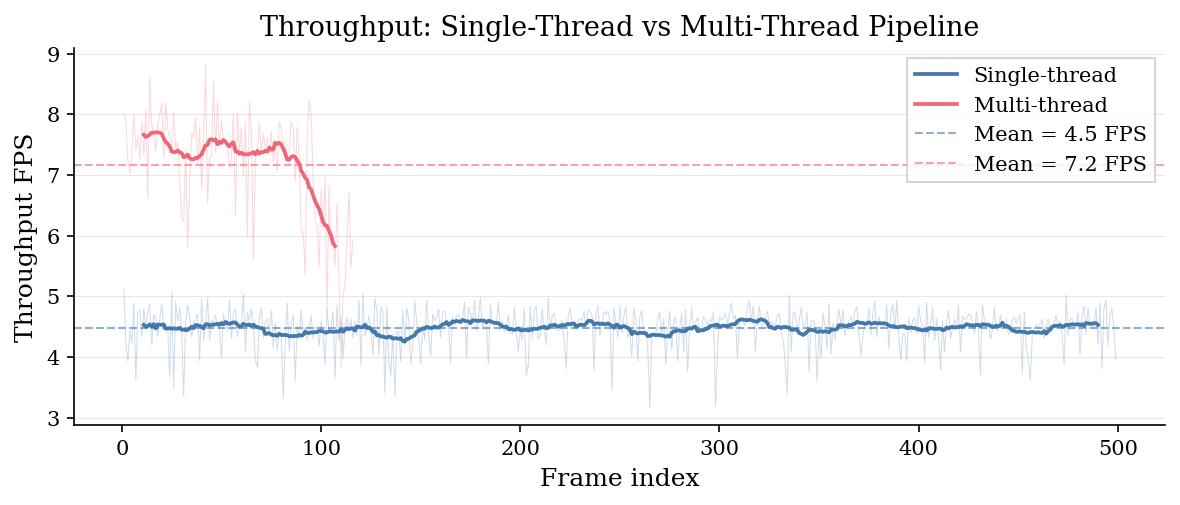

In [126]:
fig, ax = plt.subplots(figsize=(8, 3.5))

# Raw traces (faded)
ax.plot(df_st['frame_index'], df_st['throughput_fps'],
        color=C_BLUE, lw=0.5, alpha=0.25)
ax.plot(df_mt['frame_index'], df_mt['throughput_fps'],
        color=C_RED, lw=0.5, alpha=0.25)

# Rolling average
w = 20
ax.plot(df_st['frame_index'],
        df_st['throughput_fps'].rolling(w, center=True).mean(),
        color=C_BLUE, lw=1.8, label='Single-thread')
ax.plot(df_mt['frame_index'],
        df_mt['throughput_fps'].rolling(w, center=True).mean(),
        color=C_RED, lw=1.8, label='Multi-thread')

# Mean lines
mean_st = df_st['throughput_fps'].mean()
mean_mt = df_mt['throughput_fps'].mean()
ax.axhline(mean_st, color=C_BLUE, ls='--', lw=1, alpha=0.6,
           label=f'Mean = {mean_st:.1f} FPS')
ax.axhline(mean_mt, color=C_RED, ls='--', lw=1, alpha=0.6,
           label=f'Mean = {mean_mt:.1f} FPS')

ax.set_xlabel('Frame index')
ax.set_ylabel('Throughput FPS')
ax.set_title('Throughput: Single-Thread vs Multi-Thread Pipeline')
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc',
          loc='upper right')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('throughput_comparison.png', bbox_inches='tight')
plt.show()

## 5 &ensp; Latency Over Time

Per-frame latency (wall-clock time from frame creation in the producer to
completion of visualisation) plotted against frame index.

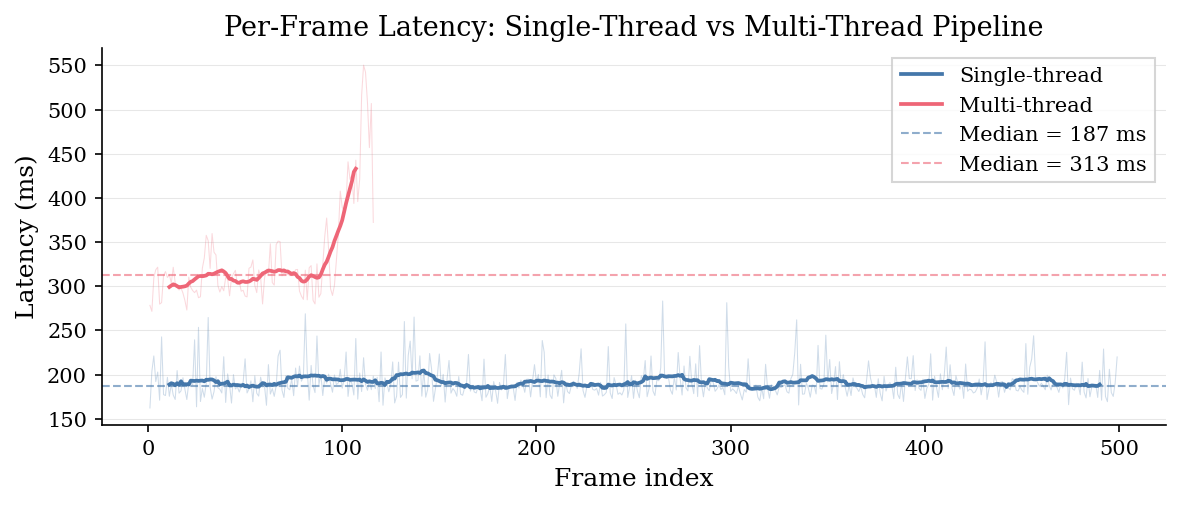

In [127]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(df_st['frame_index'], df_st['latency_ms'],
        color=C_BLUE, lw=0.5, alpha=0.25)
ax.plot(df_mt['frame_index'], df_mt['latency_ms'],
        color=C_RED, lw=0.5, alpha=0.25)

w = 20
ax.plot(df_st['frame_index'],
        df_st['latency_ms'].rolling(w, center=True).mean(),
        color=C_BLUE, lw=1.8, label='Single-thread')
ax.plot(df_mt['frame_index'],
        df_mt['latency_ms'].rolling(w, center=True).mean(),
        color=C_RED, lw=1.8, label='Multi-thread')

med_st = df_st['latency_ms'].median()
med_mt = df_mt['latency_ms'].median()
ax.axhline(med_st, color=C_BLUE, ls='--', lw=1, alpha=0.6,
           label=f'Median = {med_st:.0f} ms')
ax.axhline(med_mt, color=C_RED, ls='--', lw=1, alpha=0.6,
           label=f'Median = {med_mt:.0f} ms')

ax.set_xlabel('Frame index')
ax.set_ylabel('Latency (ms)')
ax.set_title('Per-Frame Latency: Single-Thread vs Multi-Thread Pipeline')
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc',
          loc='upper right')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('latency_comparison.png', bbox_inches='tight')
plt.show()

## 6 &ensp; Distribution Analysis

Kernel density estimates (KDE) and box plots for both latency and throughput
distributions, enabling visual comparison of central tendency and dispersion.

/tmp/ipykernel_1453424/2837118148.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_1453424/2837118148.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


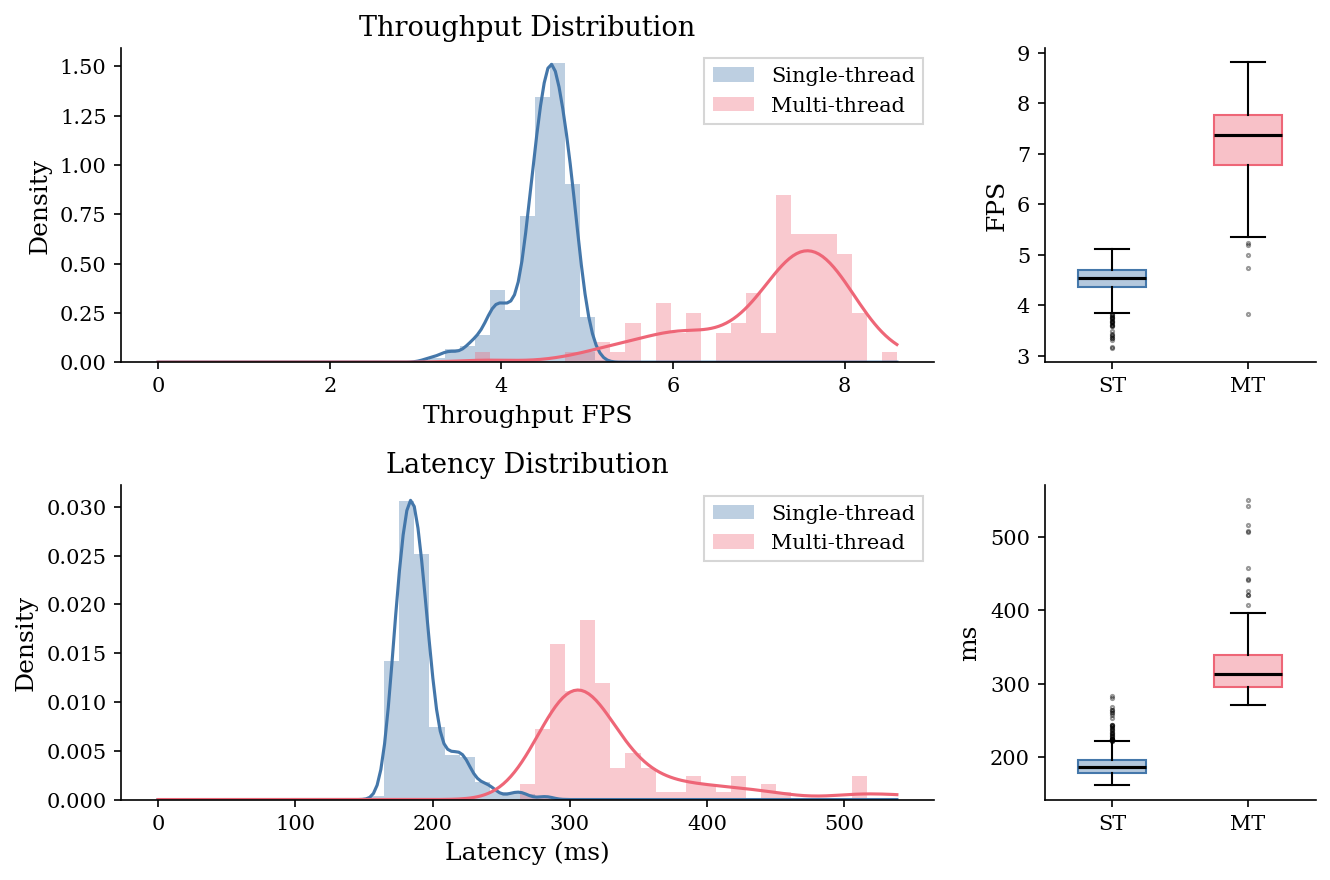

In [128]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6),
                         gridspec_kw={'width_ratios': [3, 1]})

# --- Row 0: Throughput ---
ax = axes[0, 0]
bins = np.linspace(0,
    max(df_st['throughput_fps'].quantile(0.99),
        df_mt['throughput_fps'].quantile(0.99)), 50)
ax.hist(df_st['throughput_fps'], bins=bins, density=True,
        color=C_BLUE, alpha=0.35, edgecolor='none', label='Single-thread')
ax.hist(df_mt['throughput_fps'], bins=bins, density=True,
        color=C_RED, alpha=0.35, edgecolor='none', label='Multi-thread')

# KDE curves
x_range = np.linspace(bins[0], bins[-1], 200)
kde_st = gaussian_kde(df_st['throughput_fps'].dropna())
kde_mt = gaussian_kde(df_mt['throughput_fps'].dropna())
ax.plot(x_range, kde_st(x_range), color=C_BLUE, lw=1.5)
ax.plot(x_range, kde_mt(x_range), color=C_RED, lw=1.5)
ax.set_xlabel('Throughput FPS')
ax.set_ylabel('Density')
ax.set_title('Throughput Distribution')
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc')

# Box plot
ax = axes[0, 1]
bp = ax.boxplot(
    [df_st['throughput_fps'].dropna(), df_mt['throughput_fps'].dropna()],
    labels=['ST', 'MT'], widths=0.5, patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    flierprops=dict(marker='.', markersize=3, alpha=0.4))
bp['boxes'][0].set_facecolor(C_BLUE + '66')
bp['boxes'][1].set_facecolor(C_RED + '66')
bp['boxes'][0].set_edgecolor(C_BLUE)
bp['boxes'][1].set_edgecolor(C_RED)
ax.set_ylabel('FPS')

# --- Row 1: Latency ---
ax = axes[1, 0]
bins_lat = np.linspace(0,
    max(df_st['latency_ms'].quantile(0.99),
        df_mt['latency_ms'].quantile(0.99)), 50)
ax.hist(df_st['latency_ms'], bins=bins_lat, density=True,
        color=C_BLUE, alpha=0.35, edgecolor='none', label='Single-thread')
ax.hist(df_mt['latency_ms'], bins=bins_lat, density=True,
        color=C_RED, alpha=0.35, edgecolor='none', label='Multi-thread')

kde_st_lat = gaussian_kde(df_st['latency_ms'].dropna())
kde_mt_lat = gaussian_kde(df_mt['latency_ms'].dropna())
x_lat = np.linspace(bins_lat[0], bins_lat[-1], 200)
ax.plot(x_lat, kde_st_lat(x_lat), color=C_BLUE, lw=1.5)
ax.plot(x_lat, kde_mt_lat(x_lat), color=C_RED, lw=1.5)
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Density')
ax.set_title('Latency Distribution')
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc')

# Box plot
ax = axes[1, 1]
bp = ax.boxplot(
    [df_st['latency_ms'].dropna(), df_mt['latency_ms'].dropna()],
    labels=['ST', 'MT'], widths=0.5, patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    flierprops=dict(marker='.', markersize=3, alpha=0.4))
bp['boxes'][0].set_facecolor(C_BLUE + '66')
bp['boxes'][1].set_facecolor(C_RED + '66')
bp['boxes'][0].set_edgecolor(C_BLUE)
bp['boxes'][1].set_edgecolor(C_RED)
ax.set_ylabel('ms')

plt.tight_layout()
plt.savefig('distribution_analysis.png', bbox_inches='tight')
plt.show()

## 7 &ensp; Statistical Testing

We apply a two-sided Mann–Whitney *U* test (non-parametric) to assess whether
the throughput and latency distributions differ significantly between the two
implementations. We also report the rank-biserial correlation *r* as an effect-size
measure.

In [129]:
# Throughput comparison
u_thr, p_thr = stats.mannwhitneyu(
    df_mt['throughput_fps'].dropna(),
    df_st['throughput_fps'].dropna(),
    alternative='two-sided')

# Latency comparison
u_lat, p_lat = stats.mannwhitneyu(
    df_mt['latency_ms'].dropna(),
    df_st['latency_ms'].dropna(),
    alternative='two-sided')

# Effect size (rank-biserial correlation)
n1_thr = len(df_mt['throughput_fps'].dropna())
n2_thr = len(df_st['throughput_fps'].dropna())
r_thr = 1 - (2 * u_thr) / (n1_thr * n2_thr)

n1_lat = len(df_mt['latency_ms'].dropna())
n2_lat = len(df_st['latency_ms'].dropna())
r_lat = 1 - (2 * u_lat) / (n1_lat * n2_lat)

print('Statistical Comparison (Mann\u2013Whitney U test)')
print('=' * 55)
print(f'Throughput:  U = {u_thr:.0f},  p = {p_thr:.2e},  r = {r_thr:+.3f}')
print(f'Latency:     U = {u_lat:.0f},  p = {p_lat:.2e},  r = {r_lat:+.3f}')
print()
print(f'Throughput gain: {df_mt["throughput_fps"].median():.1f} vs '
      f'{df_st["throughput_fps"].median():.1f} FPS '
      f'({df_mt["throughput_fps"].median() / df_st["throughput_fps"].median():.2f}\u00d7)')
print(f'Latency cost:    {df_mt["latency_ms"].median():.0f} vs '
      f'{df_st["latency_ms"].median():.0f} ms '
      f'({df_mt["latency_ms"].median() / df_st["latency_ms"].median():.2f}\u00d7)')

Statistical Comparison (Mann–Whitney U test)
Throughput:  U = 57310,  p = 7.44e-61,  r = -0.980
Latency:     U = 57871,  p = 3.30e-63,  r = -1.000

Throughput gain: 7.4 vs 4.5 FPS (1.63×)
Latency cost:    313 vs 187 ms (1.67×)


## 8 &ensp; Speedup & Efficiency Summary

A single visual summarising the key trade-off: throughput gain vs latency cost,
with error bars showing the IQR.

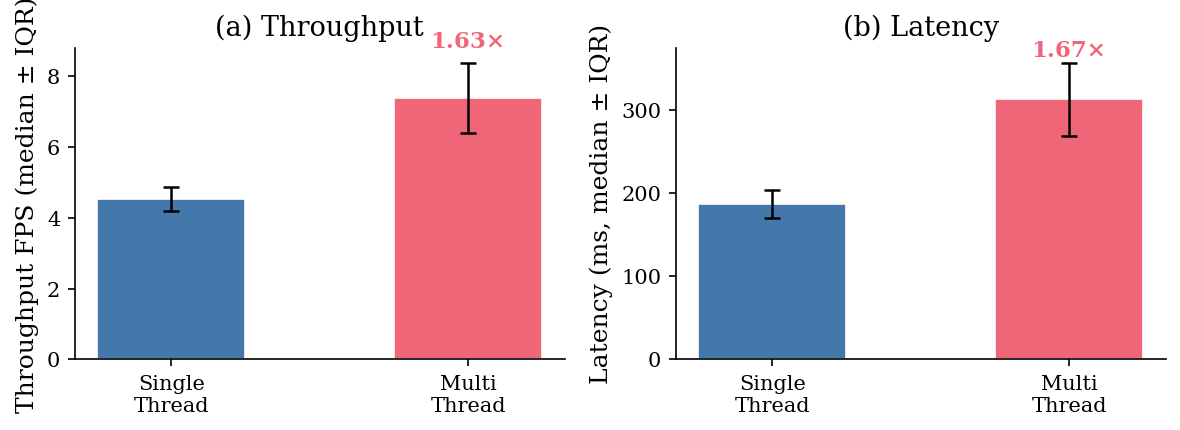

In [130]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# --- Panel A: Throughput bar chart ---
medians_thr = [df_st['throughput_fps'].median(),
               df_mt['throughput_fps'].median()]
iqrs_thr = [df_st['throughput_fps'].quantile(0.75) - df_st['throughput_fps'].quantile(0.25),
            df_mt['throughput_fps'].quantile(0.75) - df_mt['throughput_fps'].quantile(0.25)]

bars1 = ax1.bar(['Single\nThread', 'Multi\nThread'], medians_thr,
               yerr=iqrs_thr, capsize=4, width=0.5,
               color=[C_BLUE, C_RED], edgecolor='white', lw=0.8,
               error_kw=dict(lw=1.2, capthick=1.2))
ax1.set_ylabel('Throughput FPS (median \u00b1 IQR)')
ax1.set_title('(a) Throughput')

# Annotate speedup
speedup = medians_thr[1] / medians_thr[0]
ax1.annotate(f'{speedup:.2f}\u00d7',
             xy=(1, medians_thr[1] + iqrs_thr[1] + 0.3),
             ha='center', va='bottom', fontsize=11, fontweight='bold',
             color=C_RED)

# --- Panel B: Latency bar chart ---
medians_lat = [df_st['latency_ms'].median(),
               df_mt['latency_ms'].median()]
iqrs_lat = [df_st['latency_ms'].quantile(0.75) - df_st['latency_ms'].quantile(0.25),
            df_mt['latency_ms'].quantile(0.75) - df_mt['latency_ms'].quantile(0.25)]

bars2 = ax2.bar(['Single\nThread', 'Multi\nThread'], medians_lat,
               yerr=iqrs_lat, capsize=4, width=0.5,
               color=[C_BLUE, C_RED], edgecolor='white', lw=0.8,
               error_kw=dict(lw=1.2, capthick=1.2))
ax2.set_ylabel('Latency (ms, median \u00b1 IQR)')
ax2.set_title('(b) Latency')

# Annotate cost
cost = medians_lat[1] / medians_lat[0]
ax2.annotate(f'{cost:.2f}\u00d7',
             xy=(1, medians_lat[1] + iqrs_lat[1] + 2),
             ha='center', va='bottom', fontsize=11, fontweight='bold',
             color=C_RED)

plt.tight_layout()
plt.savefig('speedup_summary.png', bbox_inches='tight')
plt.show()

## 9 &ensp; Frame Drop Analysis

The multi-threaded pipeline uses a **conflated queue** that drops stale frames
when the pipeline cannot keep pace with the camera (simulated at 30 FPS).
This section quantifies the frame drop rate and its implications.

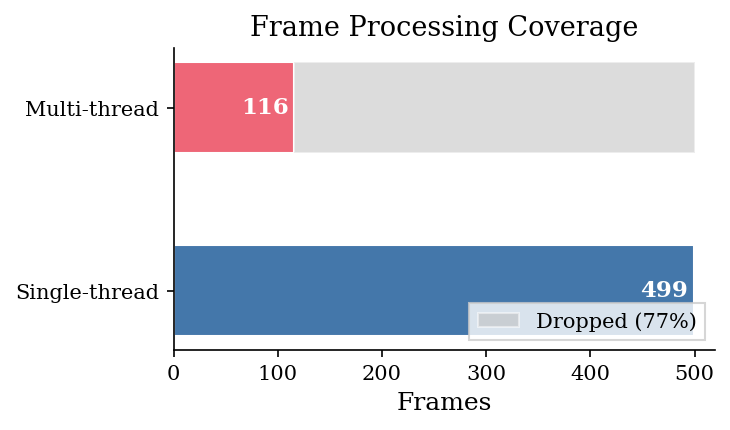

Single-thread: processed 499/500 frames (100%)
Multi-thread:  processed 116/500 frames (23.2%), dropped 384 (76.8%)


In [131]:
total_frames = 500
processed_st = len(df_st)
processed_mt = len(df_mt)

dropped = total_frames - processed_mt
drop_rate = dropped / total_frames * 100

fig, ax = plt.subplots(figsize=(5, 3))

bars = ax.barh(['Single-thread', 'Multi-thread'],
               [processed_st, processed_mt],
               color=[C_BLUE, C_RED], edgecolor='white', height=0.5)

# Dropped region for multi-thread
ax.barh(['Multi-thread'], [dropped], left=[processed_mt],
        color=C_GREY, edgecolor='white', height=0.5, alpha=0.5,
        label=f'Dropped ({drop_rate:.0f}%)')

ax.set_xlabel('Frames')
ax.set_title('Frame Processing Coverage')

# Annotate counts
for bar, val in zip(bars, [processed_st, processed_mt]):
    ax.text(val - 5, bar.get_y() + bar.get_height() / 2,
            f'{val}', ha='right', va='center', fontweight='bold',
            color='white', fontsize=11)

ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc',
          loc='lower right')
ax.set_xlim(0, total_frames + 20)
plt.tight_layout()
plt.savefig('frame_drop_analysis.png', bbox_inches='tight')
plt.show()

print(f'Single-thread: processed {processed_st}/{total_frames} frames (100%)')
print(f'Multi-thread:  processed {processed_mt}/{total_frames} frames '
      f'({processed_mt/total_frames*100:.1f}%), dropped {dropped} ({drop_rate:.1f}%)')

## 10 &ensp; Amdahl's Law: Theoretical vs Observed Speedup

We estimate the parallelisable fraction *p* from the observed throughput speedup
and compare it to Amdahl’s theoretical prediction for *N* = 4 processors.

$$\text{Speedup}(N) = \frac{1}{(1 - p) + p/N}$$

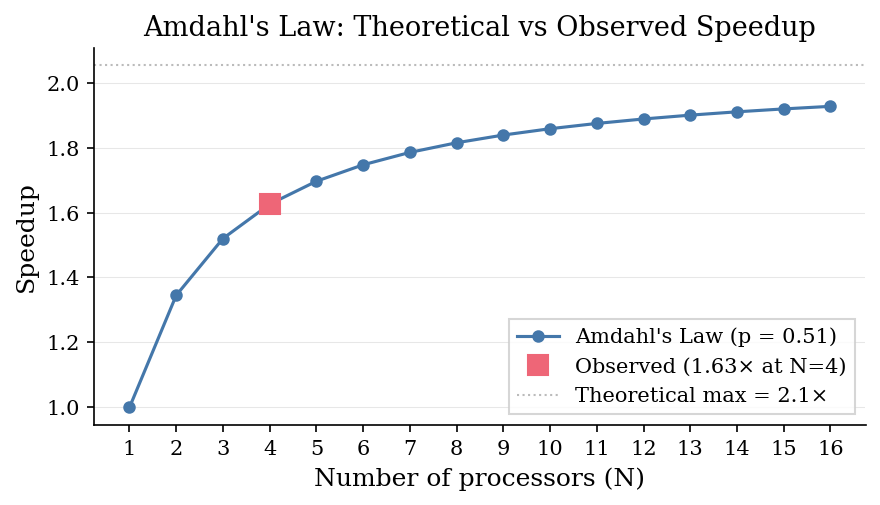

Observed speedup:        1.63×
Estimated parallel fraction (p): 51.31%
Theoretical max speedup (N→∞): 2.05×


In [132]:
observed_speedup = df_mt['throughput_fps'].median() / df_st['throughput_fps'].median()
N = 4  # number of pipeline threads

# Solve for p: speedup = 1 / ((1-p) + p/N)
# => (1-p) + p/N = 1/speedup
# => 1 - p + p/N = 1/speedup
# => 1 - p(1 - 1/N) = 1/speedup
# => p = (1 - 1/speedup) / (1 - 1/N)
p_est = (1 - 1/observed_speedup) / (1 - 1/N)

# Amdahl curve
n_range = np.arange(1, 17)
amdahl = 1 / ((1 - p_est) + p_est / n_range)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(n_range, amdahl, 'o-', color=C_BLUE, lw=1.5, markersize=5,
        label=f'Amdahl\'s Law (p = {p_est:.2f})')
ax.plot(N, observed_speedup, 's', color=C_RED, markersize=10, zorder=5,
        label=f'Observed ({observed_speedup:.2f}\u00d7 at N={N})')
ax.axhline(1 / (1 - p_est), color=C_GREY, ls=':', lw=1,
           label=f'Theoretical max = {1/(1-p_est):.1f}\u00d7')

ax.set_xlabel('Number of processors (N)')
ax.set_ylabel('Speedup')
ax.set_title('Amdahl\'s Law: Theoretical vs Observed Speedup')
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc')
ax.set_xticks(n_range)
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('amdahl_speedup.png', bbox_inches='tight')
plt.show()

print(f'Observed speedup:        {observed_speedup:.2f}\u00d7')
print(f'Estimated parallel fraction (p): {p_est:.2%}')
print(f'Theoretical max speedup (N\u2192\u221e): {1/(1-p_est):.2f}\u00d7')

## 11 &ensp; Cumulative Processing Time

Cumulative wall-clock time shows the total time budget consumed by each
implementation. The slope of the curve reflects the sustained processing rate.

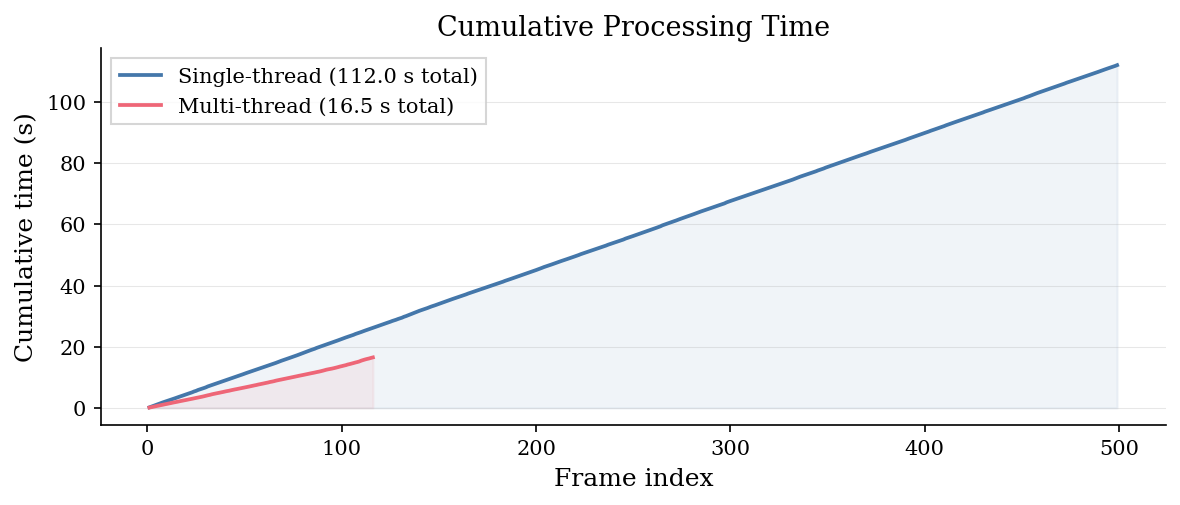

Single-thread: 499 frames in 112.0 s = 4.5 FPS effective
Multi-thread:  116 frames in 16.5 s = 7.0 FPS effective


In [133]:
fig, ax = plt.subplots(figsize=(8, 3.5))

cum_st = df_st['throughput_ms'].cumsum() / 1000
cum_mt = df_mt['throughput_ms'].cumsum() / 1000

ax.plot(df_st['frame_index'], cum_st, color=C_BLUE, lw=1.8,
        label=f'Single-thread ({cum_st.iloc[-1]:.1f} s total)')
ax.plot(df_mt['frame_index'], cum_mt, color=C_RED, lw=1.8,
        label=f'Multi-thread ({cum_mt.iloc[-1]:.1f} s total)')

ax.fill_between(df_st['frame_index'], cum_st, color=C_BLUE, alpha=0.08)
ax.fill_between(df_mt['frame_index'], cum_mt, color=C_RED, alpha=0.08)

ax.set_xlabel('Frame index')
ax.set_ylabel('Cumulative time (s)')
ax.set_title('Cumulative Processing Time')
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('cumulative_time.png', bbox_inches='tight')
plt.show()

print(f'Single-thread: {len(df_st)} frames in {cum_st.iloc[-1]:.1f} s '
      f'= {len(df_st)/cum_st.iloc[-1]:.1f} FPS effective')
print(f'Multi-thread:  {len(df_mt)} frames in {cum_mt.iloc[-1]:.1f} s '
      f'= {len(df_mt)/cum_mt.iloc[-1]:.1f} FPS effective')

## 12 &ensp; Pipeline Stage Breakdown

Per-stage timing reveals where the pipeline spends its time and identifies
the bottleneck stage. Both single-threaded and multi-threaded measurements
are compared side-by-side.

/tmp/ipykernel_1453424/2922875641.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_1453424/2922875641.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_1453424/2922875641.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


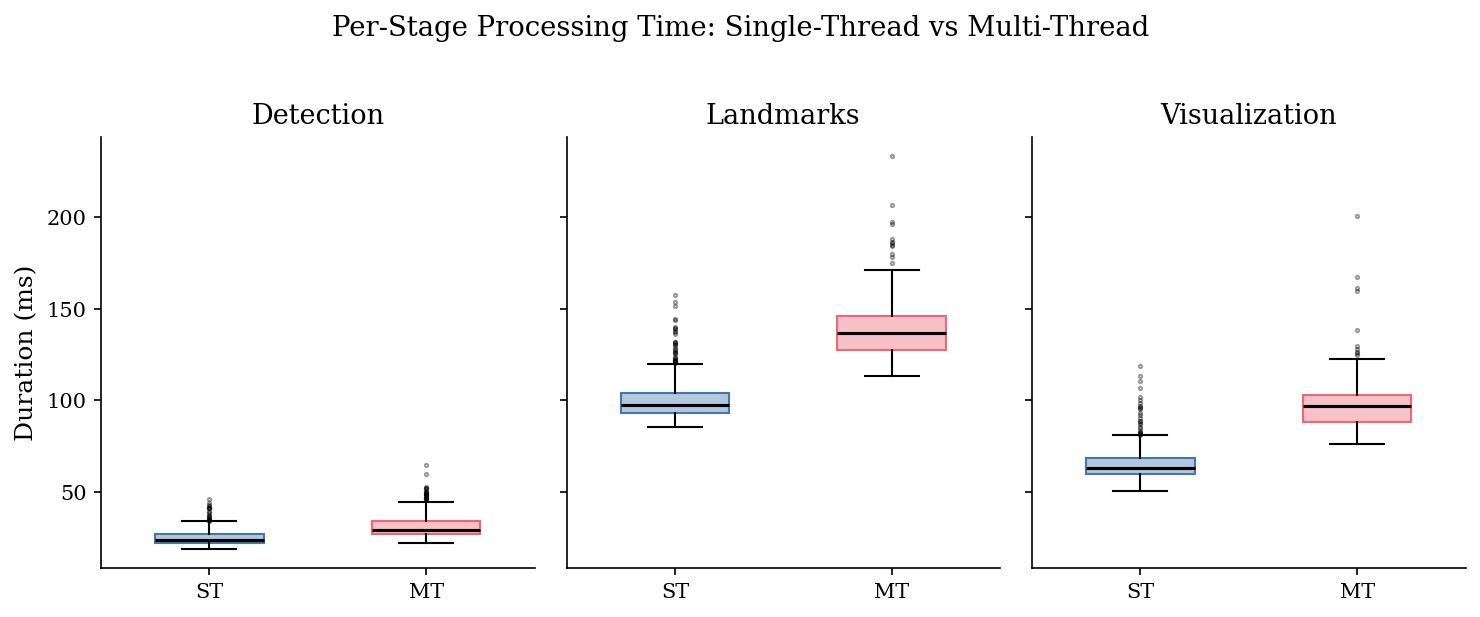


Per-Stage Summary (median ms)
detection             ST:    23.4 ms   MT:    29.4 ms
landmarks             ST:    97.5 ms   MT:   136.7 ms
visualization         ST:    63.2 ms   MT:    97.1 ms


In [134]:
stage_order = ['detection', 'landmarks', 'visualization']

fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

for i, stage in enumerate(stage_order):
    ax = axes[i]
    st_data = df_stages_st[df_stages_st['stage'] == stage]['duration_ms'].dropna()
    mt_data = df_stages_mt[df_stages_mt['stage'] == stage]['duration_ms'].dropna()

    bp = ax.boxplot(
        [st_data, mt_data],
        labels=['ST', 'MT'], widths=0.5, patch_artist=True,
        medianprops=dict(color='black', lw=1.5),
        flierprops=dict(marker='.', markersize=3, alpha=0.4))
    bp['boxes'][0].set_facecolor(C_BLUE + '66')
    bp['boxes'][0].set_edgecolor(C_BLUE)
    bp['boxes'][1].set_facecolor(C_RED + '66')
    bp['boxes'][1].set_edgecolor(C_RED)
    ax.set_title(stage.capitalize())
    if i == 0:
        ax.set_ylabel('Duration (ms)')

plt.suptitle('Per-Stage Processing Time: Single-Thread vs Multi-Thread', y=1.02)
plt.tight_layout()
plt.savefig('stage_comparison_boxplot.png', bbox_inches='tight')
plt.show()

# Summary table
print('\nPer-Stage Summary (median ms)')
print('=' * 55)
for stage in stage_order:
    st_med = df_stages_st[df_stages_st['stage'] == stage]['duration_ms'].median()
    mt_med = df_stages_mt[df_stages_mt['stage'] == stage]['duration_ms'].median()
    print(f'{stage:20s}  ST: {st_med:7.1f} ms   MT: {mt_med:7.1f} ms')

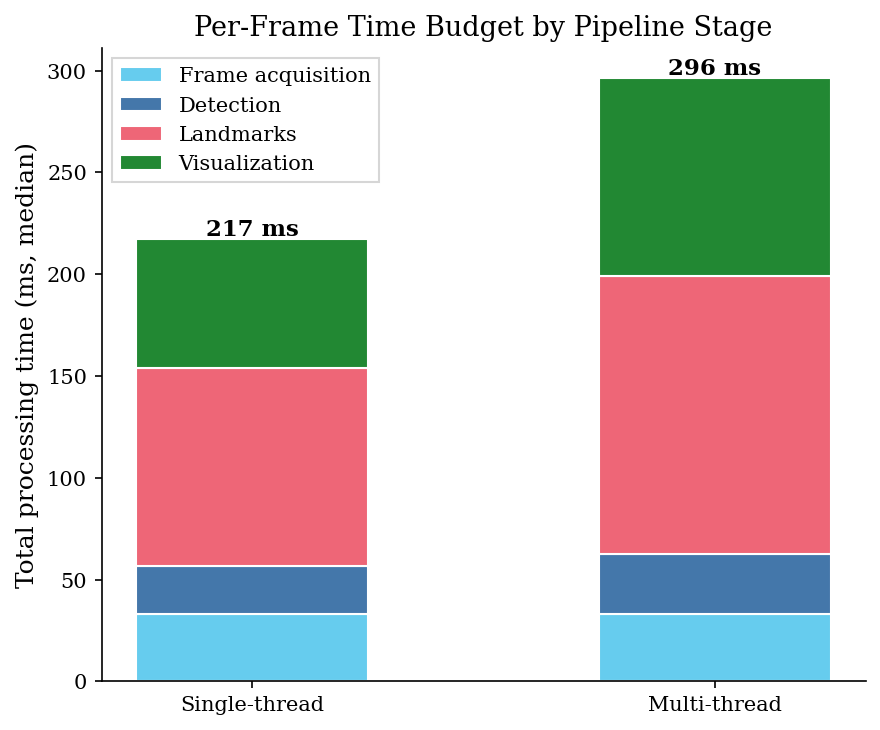


Time budget breakdown:

Single-thread (total: 217.2 ms):
  frame_acquisition        33.1 ms  ( 15.3%)
  detection                23.4 ms  ( 10.8%)
  landmarks                97.5 ms  ( 44.9%)
  visualization            63.2 ms  ( 29.1%)

Multi-thread (total: 296.3 ms):
  frame_acquisition        33.1 ms  ( 11.2%)
  detection                29.4 ms  (  9.9%)
  landmarks               136.7 ms  ( 46.1%)
  visualization            97.1 ms  ( 32.8%)


In [136]:
# --- Stacked bar: time budget per stage ---
fig, ax = plt.subplots(figsize=(6, 5))

all_stages = ['frame_acquisition', 'detection', 'landmarks', 'visualization']

st_medians = [df_stages_st[df_stages_st['stage'] == s]['duration_ms'].median() for s in all_stages]
mt_medians = [df_stages_mt[df_stages_mt['stage'] == s]['duration_ms'].median() for s in all_stages]

st_medians = [0 if np.isnan(m) else m for m in st_medians]
mt_medians = [0 if np.isnan(m) else m for m in mt_medians]

colors = [C_CYAN, C_BLUE, C_RED, C_GREEN]
x = [0, 1]

bottom_st = 0
bottom_mt = 0
for i, stage in enumerate(all_stages):
    label = stage.replace('_', ' ').capitalize()
    ax.bar(0, st_medians[i], bottom=bottom_st, color=colors[i],
           edgecolor='white', width=0.5, label=label)
    ax.bar(1, mt_medians[i], bottom=bottom_mt, color=colors[i],
           edgecolor='white', width=0.5)
    bottom_st += st_medians[i]
    bottom_mt += mt_medians[i]

ax.text(0, bottom_st + 2, f'{bottom_st:.0f} ms', ha='center', fontweight='bold')
ax.text(1, bottom_mt + 2, f'{bottom_mt:.0f} ms', ha='center', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['Single-thread', 'Multi-thread'])
ax.set_ylabel('Total processing time (ms, median)')
ax.set_title('Per-Frame Time Budget by Pipeline Stage')
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig('stage_time_budget.png', bbox_inches='tight')
plt.show()

# Percentage breakdown
print('\nTime budget breakdown:')
print('=' * 55)
for mode, medians in [('Single-thread', st_medians), ('Multi-thread', mt_medians)]:
    total = sum(medians)
    print(f'\n{mode} (total: {total:.1f} ms):')
    for stage, med in zip(all_stages, medians):
        pct = med / total * 100 if total > 0 else 0
        print(f'  {stage:20s}  {med:7.1f} ms  ({pct:5.1f}%)')

### 12.2 &ensp; Queue Wait Time vs Processing Time (Multi-Thread)

In the pipelined architecture, end-to-end latency is the sum of queue wait
times and actual processing times. This breakdown reveals how much of the
latency is overhead (waiting in queues) vs useful work.

In [ ]:
processing_stages = ['frame_acquisition', 'detection', 'landmarks', 'visualization']
queue_stages = ['queue_frame', 'queue_bbox', 'queue_landmarks']

def median_ms(df, stage):
    vals = df[df['stage'] == stage]['duration_ms']
    return vals.median() if len(vals) > 0 else 0.0

# --- Box plot: queue wait times ---
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
queue_labels = ['Frame Queue', 'BBox Queue', 'Landmarks Queue']

for i, (stage, label) in enumerate(zip(queue_stages, queue_labels)):
    ax = axes[i]
    data = df_stages_mt[df_stages_mt['stage'] == stage]['duration_ms'].dropna()
    if len(data) > 0:
        bp = ax.boxplot(
            [data], labels=['MT'], widths=0.4, patch_artist=True,
            medianprops=dict(color='black', lw=1.5),
            flierprops=dict(marker='.', markersize=3, alpha=0.4))
        bp['boxes'][0].set_facecolor(C_YELLOW + '66')
        bp['boxes'][0].set_edgecolor(C_YELLOW)
    ax.set_title(label)
    if i == 0:
        ax.set_ylabel('Wait time (ms)')

plt.suptitle('Queue Wait Times (Multi-Thread Pipeline)', y=1.02)
plt.tight_layout()
plt.savefig('queue_wait_times.png', bbox_inches='tight')
plt.show()

# --- Stacked bar: queue wait vs processing ---
fig, ax = plt.subplots(figsize=(7, 4))

proc_medians = [median_ms(df_stages_mt, s) for s in processing_stages]
queue_medians = [median_ms(df_stages_mt, s) for s in queue_stages]

total_processing = sum(proc_medians)
total_queue = sum(queue_medians)

bars = ax.barh(['Processing', 'Queue wait'],
               [total_processing, total_queue],
               color=[C_BLUE, C_YELLOW], edgecolor='white', height=0.5)

ax.set_xlabel('Time (ms, median)')
ax.set_title('Latency Breakdown: Processing vs Queue Wait (Multi-Thread)')

for bar, val in zip(bars, [total_processing, total_queue]):
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} ms', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('processing_vs_queue.png', bbox_inches='tight')
plt.show()

# --- Detailed breakdown ---
print('Multi-Thread Latency Breakdown (median ms)')
print('=' * 55)
print(f'\nProcessing stages:')
for s in processing_stages:
    v = median_ms(df_stages_mt, s)
    print(f'  {s:20s}  {v:7.1f} ms')
print(f'  {"TOTAL":20s}  {total_processing:7.1f} ms')

print(f'\nQueue wait times:')
for s, label in zip(queue_stages, queue_labels):
    v = median_ms(df_stages_mt, s)
    print(f'  {label:20s}  {v:7.1f} ms')
print(f'  {"TOTAL":20s}  {total_queue:7.1f} ms')

print(f'\nTotal (processing + queue): {total_processing + total_queue:.1f} ms')
print(f'Queue overhead: {total_queue / (total_processing + total_queue) * 100:.1f}%')

## 13 &ensp; Trade-Off Summary

| Concern | Best Choice | Reason |
|---------|-------------|--------|
| Batch / offline processing | Single-threaded | 100% frame coverage, lower latency per frame |
| Real-time display / feedback | Multi-threaded | Higher FPS output, always processes latest frame |
| Latency-critical (e.g. gesture control) | Single-threaded or hybrid | Multi-threaded queuing adds perceptible delay |
| Throughput-critical (e.g. activity monitoring) | Multi-threaded | Significantly more frames processed per second |

## 14 &ensp; Conclusions

The pipelined architecture with conflated queues demonstrates a clear
**throughput--latency trade-off**:

1. **Throughput** improves significantly as pipeline stages operate
   concurrently (detection overlaps with landmark estimation).
2. **Latency** increases due to queuing delays between pipeline stages.
3. **Frame drops** are an inherent consequence of the conflated queue
   design, which prioritises freshness over completeness.
4. **Per-stage analysis** reveals which stage dominates the time budget
   and constrains the maximum achievable pipeline throughput.

For **offline/batch** processing, the single-threaded variant (processing
all frames) is preferable. For **real-time** applications, the conflated
queue ensures the system always operates on the latest available frame,
at the cost of processing only a subset of the input.